# Developing new link performance function

## What I have done this week

1. __Cofficient of Variation(cv) check__
- cv: 2011=2024<<2014<2015
    - 2011,2024: 0.18~0.25
    - 2014: 0.35~0.4
    - 2015: 0.4~0.62
- k-means implementation
    - cv itself cannot detect the case of consistency but inaccuracy
        - the ratio of upper bound speed(90mph) over total time frames
        - implementing k-means to 1-dimension is inefficient
            - percentile or mean value is more straightforward
    - 3 clusters(2011,2024 / 2014 / 2015)
        - 2014 and 2015 look unrealistic, but no reference point to check its degree of inaccuracy
- NGSIM data
    - cv of I-80(6 lanes) during 15min: 0.08
        - q(vph): 5280/average time headway(vps)
|Variable|Lane 1|Lane 2|Lane 3|Lane 4|Lane 5|Lane 6|
|:------:|:---------------:|:---------------:|:---------------:|:---------------:|:---------------:|:---------------:|
|avg speed(mph)|40.8|17.1|16.2|13.8|15.6|19.5|
|density(vpm)|34.5|81.0|69.7|88.0|75.9|66.3|
|flow(vph)|1408|1381|1130|1218|1187|1293|98 

3. __Error screening__
- Microscopic test: abnormal signal patterns (e.g., splashover, pulse breakup)
    - splashover: the erroneous detection in one lane of a vehicle from an adjacent lane
    - pulse breakup: a vehicle should register a single pulse per detector in its lane of travel but instead a detector momentarily drops out in the middle of the vehicle and produces two or more pulses
- Macroscopic test: aggregated traffic flow relationships (e.g., flow, occupancy, and speed)
    - Setting thresholds
        - single-variables: Paynes et al.(1976),
        - Mathematical relationships between traffic flow variables:
            - Cleghorn et al.(1991): upper bound of flow-occupancy ratio at the uncongested traffic state
    - Spatial relationship from direct upstream and downstream detectors: Nihan(1997), Chen et al.(2003), Wall et al. (2003)
    - Screening for dual loop detectors(after 2000)
        - __Average effective vehicle length(AEVL), which is equal to g-factor, has been widely used: threshold based__
            - why?) Can be calculated at the dual loop detector
            - why?) it is robust to traffic anomalies such as incidents or bad weather, traffic states
    
3. __how g-factor is calculated__
- single-loop detector
    - The PeMS algorithm(Zhanfeng, Coifman, et al.(2001))
        - Determine the g-factor in an uncongested traffic state using the measured q and occupancy, assuming free-flow speed.
            - $g_{instant}(t)=\frac{o(t)}{q(t)}\times u_{free}$ ($o(t)$: occupancy, $q(t)$: flow rates(vph), $u_{free}$ : 65mph) 
        - Then, adjust the g-factor for congested periods using historical data. (historical g-factor data are given)
            - $g(t) = g_{instant}(t) + [g_{hist}(t+\tau)-g_{hist}(t)]$ ($g_{hist}(t): \text{historical g-factor at time t}, \tau: \text{delay time(hr)}$)
- dual-loop detector
    - calculated by u,q,occ:
        - $g(t)=\frac{o(t)}{q(t)}\times \bar{u}(t)$ (o(t): occupancy, q(t): flow rates(vph), u:velocity(mph))

3. __ideas for datasets screening__
- g-factor: compare g-factor from PeMs with calculated g-factor assuming free-flow speeds(60mph) at the early morning or late night time
- Adopt PeMS health dataset criteria: 'occ=0', 'Flow=0','High occ', 'High flow', 'Flow=0 & Occ>0', 'Flow>0 & Occ=0', 'Rpt(Repeat) Occ'
- Conservation laws: conservation between q vs k needs to be guaranteed?
- Jared Sun: find inconsistent lanes


## Memo
   
1. __PeMs User Guide__
    - Speed
        - the speed is either measured directly: possible with radar detectors
        - calculated: using a g-factor accompanying the flow and occupancy as with single-loop detector
        - Our location is double-loop and mentioned as "speeds are estimated" 
        - For the aggregate speed that spans all of the loops, the speed is the flow-weighted mean across the lanes.
    - g-factor
        - The g-factor is a conversion factor used to convert the measured quantities of flow and occupancy into speed for detectors that do not measure speed directly. The g-factor is a combination of two quantities: __1)__ the average length of the vehicles traveling over the detector and __2)__ the tuning of the detector. Each detector in the system has its own tuning characteristics. PeMS calculates a g-factor for every single detector over __every 5-minute period__ for an entire week. By doing this, PeMS captures the weekly characteristics of the traffic mix as well as the individual characteristics of each detector.
        - However, a specific lane or lanes have not been designated on a divided highway having four or more clearly marked lanes for traffic in one direction, ... those vehicles may also be driven in the lane to the immediate left of that right-hand lane [link](https://dot.ca.gov/programs/traffic-operations/legal-truck-access/truck-lane-use#:~:text=those%20vehicles%20shall%20be%20driven,the%20right%20edge%20or%20curb.)
     
2. __Capacity drop__
- Capacity drop refers to when the q-k curve does not follow the F.D., but rather shows a horizontally dispersed at the certain level of point
- The commonly well-known case is at the intersection
    - At the intersection, when the light turns green and cars start moving, even if there's nothing blocking their way, the flow of traffic doesn't reach full capacity because there aren't enough cars to fill up the road.
    - In this stationary case, data from loop detectors, which monitor both the traffic coming towards the intersection and the traffic leaving it, show that the average density spreads out within the density of upstream and downstream traffic.
    - This leads to a trapezoid shape on the traffic flow diagram. Instead of reaching a peak, the points on the diagram spread out horizontally at a certain level.
    - Likewise, the bottleneck shows this pattern as vehicles got stuck at the merging point.
- If the road is really long, you'd expect the traffic jam to be super dense, but that's not necessarily the case because of physical limits.

3. __Qiinlong's paper__
- Theme: Automatic identification of near-stationary traffic states
    - The major contributwasnto develop method toelop automatically select the candidates for stationary time series.
    - And then apply Cassidy(1998) method to finally determine near-stationary state__s
- why SR-9__1 E? can detect stationary equilibrium state(70ft above from the merging point)

4. __SR-91, EB, (VDS 1203506)__
- about 70ft upstream from the merge point(Valley-view, bottleneck)
- EB: But this road is not that much related with commute trip, so it showed one-peak point.

5. __BPR function__
- BRP function can only be defined on a congested part(also can verify in the Vickery)
    - BPR function is the relationship of the supply and demand equilibrium state, and the equilibrium happens only at the congested state
    - so, based on the defined BPR at the congested period, we can derive fundamental diagram at the congested period.
- The next step after defining BPR is to define F.D.
    - By individually defining the F.D. for each side, we can determine the length of flat line in the middle.
- Only applicable for the two-peak cases
- If the proportion of volumes is constant, it can be expanded to the whole day.

6. __Peak-period finding__
- how to define the peak period

7. __g-factor__
- 2011: 24 ~ 26ft for lane 3, 19~22ft for the rest of lanes
- 2014: varies a lot
- Reference
    - compact: 10~14ft
    - midsize: 14~16ft
    - large-SUV: 16.7ft
    - fullsize: 16~18ft
    - Large pickup: 18.4ft 

# Weekly meeting
- [weekley meeting collection](https://github.com/jooneui/BPR/blob/main/.ipynb_checkpoints/Weekly_meeting_BPR_function-checkpoint.ipynb)

# 0. Variable Definition 
- Need to check it again
- Time
    - $\bar{t}$: Average time to move unit distance (min/mile)
    - $t_0$: Free-flow travel time (min)
    - $T$: Given(??) time period (hr)

- Flow
    - $N$: Daily Traffic volume (vpd) ($= N_0 \times l$, $l$: The number of lanes)
    - $N_0$: Daily Traffic volume per lane (vpdpl)
    - $C$: Road capacity (vpd) ($= C_0 \times l$)
    - $C_0$: Road capacity per lane(vpdpl) = 32,000vpd
    - $\bar{C}$: Pratical capacity (vpd)
    - $q$: Flow rate per lane(vphpl)

- Speed
    - $\bar{v}$: Average speed(mph)
    - $\mu$: Free-flow speed(mph)
- Density
    - $k$: Density(vpm)
    - $k_c$: Critical density(vpm)
    - $k_j$: Jam density(vpm)
- Etc
    - $d$: Loop detector length(m)
    - $l$: The number of lanes

# 1. Introduction

## 1.1. The importance of Volume-Delay function(VDF)

- VDF is a critical component of traffic assignment, quantifying travel time caused by observed volume and road capacity(Kucharski and Drabicki 2017)
- VDF establishes the relationship between travel time, road traffic volume, and dynamic traffic state (Branston 1976; Nie and Zhang 2005; Patriksson 2015)
- Accurate estimation and calibration of the current traffic demand and supply are crucial in identifying and addressing congested or oversaturated conditions (Yuyan Pan et al. 2023)

## 1.2. BPR function
- The Bureau of Public Roads (BPR), Davidson’s, Akcelik’s, and conical delay functions are the most commonly used link cost functions.
- The BPR function has profound applications in transportation planning primarily as a result of its simple mathematical form, easily observable field inputs, and consistent performance (Mtoi and Ren, 2014; Das and Rama Chilukuri, 2020)
- BPR function: $t=t_0(1+\alpha(\frac{N}{C})^\beta)$
    - $\alpha$ is the scale parameter
        - how the congestion effects change when the capacity is reached(Spiess, 1990)
    - $\beta$ is a shape parameter

## 1.3. Problem Statement

- ① BPR has not adequately incorporated fundamental diagrams(FD)
    - BPR function
        - $\bar{t}=\frac{1}{\bar{v}}=t_0[1+\alpha(\frac{N}{C})^\beta]$ ($N=qT$)
    - Triangular F.D.
        - $\bar{t} = \begin{cases} \frac{1}{\mu} \text{  (if  } k < k_c) \\ \frac{Tk_j}{N} - \frac{1}{\omega} \text{  (if  } k > k_c) \end{cases}$ [Appendix 1]
    - Simply employing $N/C$ in the BPR fails to accurately depict the shape of FD

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def BPR_function(t_0,C,alpha,beta,N):
    t =  t_0 * (1+alpha*(N/C)**beta)
    return t

def Triangular_FD_congested(q,k_j,w):
    t = (k_j/q-1/w)*60
    return t

Text(0.5, 1.0, 'BPR vs Triangular F.D.')

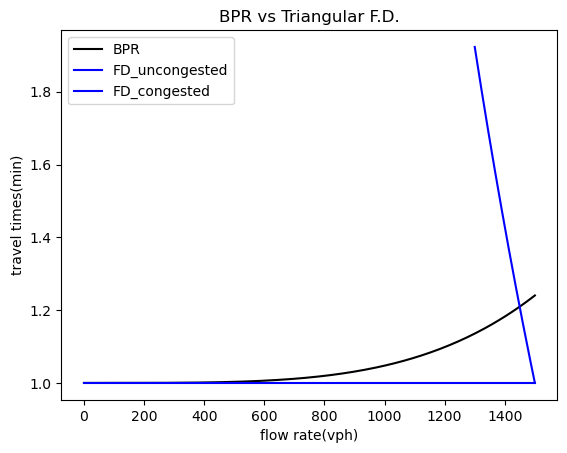

In [4]:
# 1. Variable Definition
# Unit: q:vph, C: vpd, k_j: vpm, mu: mph, tau: sec, w: vpm, t_0: min
q = np.linspace(0,1500,200)
q_c = np.linspace(1300,1500,200)
T = 24
N = q * T
C = 32000
k_j = 150
tau = 2 
mu = 60
w = 1/(tau * k_j)*3600
alpha = 0.15
beta = 4
t_0 = 1/mu*60

# 2. calculate the function value

t_BPR = BPR_function(t_0,C,alpha,beta,N)

t_FD_u = np.repeat(t_0,200)
t_FD_c = Triangular_FD_congested(q_c,k_j,w)

# 3. plot 
plt.plot(q,t_BPR, color='black',label = 'BPR')
plt.plot(q,t_FD_u, color='blue',label = 'FD_uncongested')
plt.plot(q_c,t_FD_c, color='blue',label = 'FD_congested')
plt.legend(fontsize = 10)
plt.xlabel('flow rate(vph)')
plt.ylabel('travel times(min)')
plt.title('BPR vs Triangular F.D.')

## 1.3. Problem Statement(Cont)
- ② Discrepancy with the original paper(BPR, 1964)
    - There are discrepancies in how variables are used between the original paper(BRP, 1964) and pratical application.
||BPR(1964)|Practical Usage|
|:------:|:------------------:|-------------------------|
|Expression|$t=t_0(1+\alpha(\frac{N}{\tilde{C}})^\beta)$|$t=t_0(1+\alpha(\frac{N}{C})^\beta)$|
|$N$|Assigned volume(vpd)| Daily Traffic volume(??) (vpd)   |
|$C$ or $\tilde{C}$|Practical capacity(vpd) $\approx 32,000vpd$| Road capacity(vpd)|
    
    - Practical capacity is much less than general road capacity, leading to a possible case of $N>C$
        - The original paper also addressed this case as an example.
    - However, in the measured data, it is impossible to directly observe the case where V/C is greater than 1.(Yuyan Pan et al. 2023)
- Therefore, it is necessary to redefine the demand-supply relation($N/C$) that resolves the both drawbacks of BPR
    - replacing the practical capacity with higher value does not resolve the first issue: The incorporation of FD into BPR
- <span style="color:red"> Q) I would like to discuss the interpretation of practical capacity($\tilde{C}$)</span>
    - <span style="color:red"> The practical capacity of 32,000vpd mentioned in BPR(1964) applies specifically to link 3403-3406. What if the link has only one lane? If then, the practical capacity varies based on the number of lanes in each link. For instance, a two-lane link may have a practical capacity of 64,000vp. I think this statement is more logical considering the varying road capacity depending on the number of lanes. </span>





## 1.4. Objective

- Propose advanced BPR function by newly defining traffic demand
    - Traffic demand refers to the amount of vehicular or pedestrian traffic that is __expected or desired__ in a particular area or on a particular roadway
        - Measure of the need for transportation infrastructure
- Let's newly define traffic demand as $N'=q\cdot T(N)$, where $N'$ stands for desired trafffic volume and $w$ as road capacity(vph)
    - __$T(N)$: the intensity of demand__(이거 설명 필요)
    - <span style="color:red"> Q) What about using T(k) instead of T(N) as N itself cannot distinguish between hyper- and under-congested. </span> 
        - (ex. $T(N)=\frac{N}{q}$)
            - $N$: Traffic volume (vpd)
            - $q$: Annual average daily traffic (vph)
            - $T$: Observed time period (hr)
    - $w$: capacity(vpd?)
        - __How can we define it? As Wished time windows need to be handled in time windows??__(이거)
- Three cases for defining $N'$ 
    - All-day: $T(N)$=24 & w are similar during the normal weekdays
    - peak
    - non-peak
        - __Q) If $T(N)$ is a linear function of $N$, and $w$ is not function of $N$, how about plotting $N^2$ vs $\bar{z}$, and check if it follows BPR shape?__        
- 어떻게 할 수 있을까??
    - demand derivation 할 수 있을까?? 먼저 추세를 보자!!

## Appendix

- 1. Triangular Fundamental Diagram
    - $k \ge k_c$
        - $q = \omega(k_j-k)$
        - $k = k_j-\frac{q}{\omega}$
        - $v = \frac{q}{k}=\frac{\omega q}{\omega k_j - q}=\frac{\omega q}{\omega \times \frac{\mu+\omega}{\mu\omega}C-q}=\frac{\omega q}{\frac{\mu+\omega}{\mu}C-q}=\frac{\mu\omega q}{\mu(C-q)+wC}$
        - $z=\frac{1}{v}=\frac{\mu(C-q)+\omega C}{\mu \omega q}=\frac{C(\mu+\omega)}{\mu \omega q}-\frac{1}{\omega}=\frac{k_j}{q}-\frac{1}{\omega}$
        - cf) $\bar{z}=\frac{\int_0^T z(t)q(t) dt}{\int_0^T q dt}=\frac{\int_0^T k_j-\frac{q}{\omega}dt}{\int_0^T q dt}=\frac{k_j T - \frac{\bar{q}T}{\omega}}{\bar{q}T}=\frac{k_j}{\bar{q}}-\frac{1}{\omega}=\frac{Tk_j}{N}-\frac{1}{\omega}$
    - $k \lt k_c$
        - $v = \mu$
        - $z = \frac{1}{v}=\frac{1}{\mu}$
        

# 2. Literature Review

- __Papers__
    - __Yuyan Annie Pan et al., 2023__
        - Background
            - Exisiting VDFs have not adequately incorporated fundamental diagrams(FD)
        - Objective
            - An improved VDF is proposed, based on the FD by integrating the traffic flow model into the VDF.
                - Only using one parameter $m$, refering to maximum flow inertia coefficient
            - The proposed VDF will be tested and validated in two cases: Beijing and LA
                - New model performs better than existing models with respect to RMSE and MAE
        - [Methodology](./Yuyan_Annie_Pan_2023.ipynb)
            - The hypercongested region of the FD experiences a left-right symmetric shift with $x=v/C=1$ as the reference point.
            - <center> <img src="https://github.com/jooneui/fig_collection/blob/main/Fig2.png?raw=true", width = 70%>
            - $tt= \begin{cases} t_0 \cdot [\frac{2}{1+\sqrt{1-(\frac{V}{C})^m}}]^{\frac{2}{m}}, \text{  if  } V/C \lt 1 \\  t_0 \cdot [\frac{2}{1-\sqrt{1-(2-\frac{V}{C})^m}}]^\frac{2}{m}, \text{  if  } V/C > 1 \end{cases}$
- BPR drawbacks
    - fails to accurately capture the dynamics of traffic flow (Pan et al., 2022) and queue evolution(Cheng et al. 2022; Zhou et al. 2022)
    - its accuaracy decreases with higher values of $\beta$(Spiess 1990)
- Other VDFs
    - Davidson(1966, 1978): based on queueing theory
    - Akcelik(1979,1991): linear extension of Davidson's function
    - Tisato(1991): modified version Davidson's model, addressing congestion duration during oversaturated conditions
    - Spiess(1990): canonical function
    - Zhou et al.(2022): improved version of Spiess

# 3. Methodology
## 3.1. Flow chart
- <span style="color:red"> Q) For the raw data, I use $q$ to represent flow rates and $\bar{v}$ to denote the average velocity of vehicles. I would like to discuss its appropriateness. </span>
- <span style="color:red"> I need to add steps for the Peak/Non-peak cases </span>

<center> <img src="https://github.com/jooneui/fig_collection/blob/main/Fig1.png?raw=true", width = "70%"> </center>

# 4. Data Description
- Lane information(ex. HOT)
    - NO HOT, but only HOV.
    - VDS does not cover the HOV lane, but only for general-purpose lanes(4 out of 5 lanes).
    - HOT in SR 91: SR 91 with the SR 55 Freeway (Costa Mesa Freeway) in Anaheim to its junction with I-15 in Corona(18 miles)
      
    <center> <img src="https://ars.els-cdn.com/content/image/1-s2.0-S0191261517311050-gr9.jpg", width = 40%> </center>
- Check consistency with Qinglong Yan et al.(2018); critical density, free-flow speed, etc.
    - Yan et al. 2018. 
        - Nine months (Jan., Feb., Mar., Apr., May, July, Sept., Oct., and Nov.) in 2011 with the sample size of 273 days
        - 30sec data
        - Using flow-rate and occupancy
        - Critical occ: 0.164




# 5. Results
- __All-day case__
    - The current outcome doesn't exhibit a clear pattern and doesn't appear to resemble the shape of a BPR function. 
To grasp the overall shape of the results, additional data with a different rang is required
- __Plan to analysis__
    - ①  The datasets from August 2019, September 2019, October 2023, and November 2023 exhibit minimal variance
         - The Average Annual Daily Traffic (AADT) from 2019 to 2023 remains stable
        - It is essential to include datasets from a different time frame, specifically the 2014-2015 dataset
        - Comparatively, the demand during 2014-2015 was significantly higher than that of 2019-2023
    - ② The rawdata with different timeframe(15min, 1hour) needs to be applied.
    
- <center> <img src="https://github.com/jooneui/fig_collection/blob/main/AADT_2013-2024.png?raw=true", width = "80%"> </center>

In [161]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

import xlrd
import os
from time import time
import datetime as dt
from dateutil.parser import parse
import math
from scipy.signal import find_peaks
import pickle
import csv

from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

import warnings
warnings.filterwarnings('ignore')

In [219]:
veh_traj_raw = pd.read_csv('C:/Users/wnsdm/OneDrive - UC Irvine/11 research/04 Ximeng work/rawdata/raw_camera65.csv',
                           usecols = ['Vehicle_ID', 'Frame_ID', 'Global_Time','v_Vel','v_Acc', 'Lane_ID', 'Preceding', 'Following', 'Space_Headway', 'Time_Headway'])

veh_traj_raw['combined_id'] = veh_traj_raw['Vehicle_ID']*10000 + veh_traj_raw['Preceding']


grouped_lane = veh_traj_raw.groupby('Lane_ID')

NGSIM_s_raw = [[],[],[],[],[],[]]
NGSIM_t_raw = [[],[],[],[],[],[]]

for name, group in grouped_lane:

    vehicle_keys = group['combined_id'].unique()
    grouped_lane_vehid = group.groupby('combined_id')
    
    for id in vehicle_keys:
               
        vehicle_derivatives = []
        time_headway_upper = 100
        mask = (grouped_lane_vehid.get_group(id)['Space_Headway'] > 0) & (grouped_lane_vehid.get_group(id)['Time_Headway'] < time_headway_upper)
        grouped_lane_vehid_filter = grouped_lane_vehid.get_group(id)[mask]

        if len(grouped_lane_vehid_filter) > 0:
            group_sheadway, group_theadway = grouped_lane_vehid_filter[['Space_Headway','Time_Headway']].mean(axis=0)
        
            if (group_sheadway > 0):
                NGSIM_s_raw[name-1].append(group_sheadway)
                NGSIM_t_raw[name-1].append(group_theadway)

NGSIM_density = [5280/np.mean(NGSIM_s_raw[i]) for i in range(len(NGSIM_s_raw))]
NGSIM_flow = [3600/np.mean(NGSIM_t_raw[i]) for i in range(len(NGSIM_t_raw))]
NGSIM_speed = [NGSIM_flow[i]/NGSIM_density[i] for i in range(len(NGSIM_flow))]

print('density',NGSIM_density)
print('flow',NGSIM_flow)
print('speed',NGSIM_speed)

print('coefficient of variation',np.std(NGSIM_flow)/np.mean(NGSIM_flow))

density [34.47669619307923, 80.97460968127302, 69.68610307931341, 88.02730771119893, 75.9128655449042, 66.32515973962099]
flow [1408.0228555210438, 1380.7202921254764, 1129.5171278662795, 1217.9742989164642, 1186.7301645113891, 1293.372682145626]
speed [40.83984287925149, 17.051274437260982, 16.208642440239725, 13.836323415824658, 15.6327936772379, 19.500483485047646]
coefficient of variation 0.07958095535804798


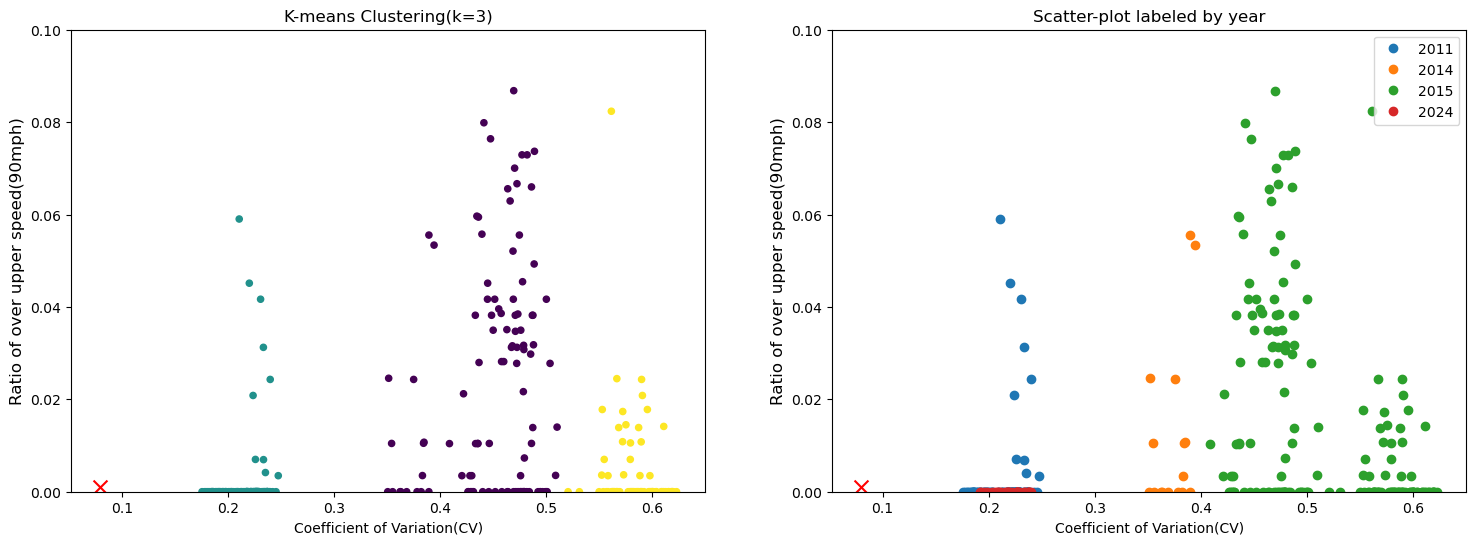

In [221]:
with open('df_kmeans.p', 'rb') as file:
    df_kmeans = pickle.load(file)

# Assuming cv_list[:, 1] is your 1D data that was used for KMeans
data_2d = df_kmeans.iloc[:, 2:4]

# Use KMeans to cluster the data into 3 clusters
num_clusters = 3
kmeans = KMeans(num_clusters)
kmeans.fit(data_2d)

# Predict the cluster for each data point
y_kmeans = kmeans.predict(data_2d)

# Plot the clustered data
fig, ax = plt.subplots(1,2,figsize=(18,6))

ax[0].scatter(data_2d['cv'], data_2d['over_speed_ratio'], c=y_kmeans, s=20, cmap='viridis')

# Plot the centroids
centroids = kmeans.cluster_centers_

ax[0].set_ylim(0,0.1)
ax[0].set_ylabel(f'Ratio of over upper speed({speed_bound}mph)',fontsize = 12)

ax[0].set_title(f'K-means Clustering(k={num_clusters})')
ax[0].set_xlabel('Coefficient of Variation(CV)')

df_kmeans_group = df_kmeans.groupby('year')

for name, group in df_kmeans_group:
    ax[1].plot(group["cv"], group["over_speed_ratio"], marker="o", linestyle="", label=f"{name}")

ax[1].set_title('Scatter-plot labeled by year')
ax[1].set_ylim(0,0.1)
ax[1].set_xlabel('Coefficient of Variation(CV)')
ax[1].set_ylabel(f'Ratio of over upper speed({speed_bound}mph)',fontsize = 12)

ax[1].legend()

ax[0].scatter(np.std(NGSIM_flow)/np.mean(NGSIM_flow),0.001,marker = 'x',color = 'red', s = 100)
ax[1].scatter(np.std(NGSIM_flow)/np.mean(NGSIM_flow),0.001,marker = 'x',color = 'red', s = 100)


plt.show()

In [214]:
## set parameters for uploading data
# time_frame(min) related parameters(sec,5min,15min,1hour)
raw_timeframe = 0.5
directory = '30sec'
path = 'C:/Users/wnsdm/OneDrive - UC Irvine/14 Github/BPR/11 Rawdata'
file_list = os.listdir(f'{path}/{directory}')
# lane number related parameters
lane_num = [1,2,3,4]

os.getcwd()
print(file_list)

['Rawdata_110101.xlsx', 'Rawdata_110102.xlsx', 'Rawdata_110103.xlsx', 'Rawdata_110104.xlsx', 'Rawdata_110105.xlsx', 'Rawdata_110106.xlsx', 'Rawdata_110107.xlsx', 'Rawdata_110108.xlsx', 'Rawdata_110109.xlsx', 'Rawdata_110110.xlsx', 'Rawdata_110111.xlsx', 'Rawdata_110112.xlsx', 'Rawdata_110113.xlsx', 'Rawdata_110114.xlsx', 'Rawdata_110115.xlsx', 'Rawdata_110116.xlsx', 'Rawdata_110117.xlsx', 'Rawdata_110118.xlsx', 'Rawdata_110119.xlsx', 'Rawdata_110120.xlsx', 'Rawdata_110121.xlsx', 'Rawdata_110122.xlsx', 'Rawdata_110123.xlsx', 'Rawdata_110124.xlsx', 'Rawdata_110125.xlsx', 'Rawdata_110126.xlsx', 'Rawdata_110127.xlsx', 'Rawdata_110128.xlsx', 'Rawdata_110129.xlsx', 'Rawdata_110130.xlsx', 'Rawdata_110131.xlsx', 'Rawdata_110201.xlsx', 'Rawdata_110202.xlsx', 'Rawdata_110203.xlsx', 'Rawdata_110204.xlsx', 'Rawdata_110205.xlsx', 'Rawdata_110206.xlsx', 'Rawdata_110207.xlsx', 'Rawdata_110208.xlsx', 'Rawdata_110209.xlsx', 'Rawdata_110210.xlsx', 'Rawdata_110211.xlsx', 'Rawdata_110212.xlsx', 'Rawdata_1

In [168]:
def avg_traffic_state(rawdata, time_frame, lane_num, gfactor):
    """
    Calculate average traffic state parameters based on raw traffic data.

    Parameters:
    - raw_data: DataFrame, contains raw traffic data with columns 'flow_1', 'flow_2', 'flow_3', 'flow_4',
                'occ_1', 'occ_2', 'occ_3', 'occ_4'
    - time_frame: int, time frame for the data in minutes (e.g., 5 minutes)
    - lane_num: lane number to analyze(ex. lane_num = [1,2,3,4]

    Returns:
    - avg_speed: float, average speed in miles per hour(mph)
    - avg_time: float, average time in minutes per mile(min/mile)
    - avg_flow: float, average flow in vehicles per hour per lane(vph)
    - avg_density: float, average density in vehicles per mile per lane(vpm)
    """
    # Step 0: Select the lane numbers for extracting data 
    flow_variable = [f'flow_{lane}' for lane in lane_num]
    occ_variable = [f'occ_{lane}' for lane in lane_num]
    gfactor_variable = [f'Lane {lane}' for lane in lane_num]

    # Step 1: Read rawdata
    # Step 1-1: Read volume data and transfer to flow-rates (vehicles per hour)
    rawdata_flow = np.array(rawdata[flow_variable] * (60 / time_frame))
    
    # Step 1-2: Read occupancy data(%) and divide by 100
    rawdata_occ = np.array(rawdata[occ_variable])/100
    
    # Step 1-3: Read gfactor and dulplicate it to the total number of rows
    # gfactor['Time'] = pd.to_datetime(gfactor['Time']).dt.hour

    # Define a lambda function to format the time in the HH:MM format, recognize it as a date, and extract its hour.
    gfactor['Time'] = gfactor['Time'].apply(lambda x: f"{x:02}:00" if isinstance(x, int) else x)
    gfactor['Time'] = pd.to_datetime(gfactor['Time'], format='%H:%M').dt.hour
    
    rawdata_gfactor = pd.merge(rawdata, gfactor, how='left', left_on='time_hour', right_on='Time')[gfactor_variable]
    ## fill NA gfactor as an average of the rest
    rawdata_gfactor = rawdata_gfactor.fillna(rawdata_gfactor.mean())
    
    # Step 2: calculate individual lane's density and speed
    # Step 2-1: Calculate average density(vpm)
    rawdata_density = rawdata_occ * 5280 / rawdata_gfactor
    # Step 2-2: Calculate average speed(mph)
    rawdata_speed = rawdata_flow / rawdata_density 
    
    # Step 3: calculate aggreate density & speed & flow
    # Step 3-1: Flattening the flow and speed
    rawdata_flow = np.array(rawdata_flow).flatten()
    rawdata_speed = np.array(rawdata_speed).flatten()
    
    # Step 3-2: Calculate aggregate speed(sum_product = sum of flow/sum_product)
    ## sum_flow: sum of all flow-rates
    ## sum_product: sum of (flow-rates/average speed)
    sum_flow = rawdata_flow.sum()
    # Safely compute the multiplication, avoiding division by zero and handling NaN values
    with np.errstate(divide='ignore', invalid='ignore'):
        multiply = np.multiply(rawdata_flow, np.where(rawdata_speed != 0, 1.0 / rawdata_speed, np.nan))
    # Sum the non-NaN results directly
    sum_product = np.nansum(multiply)
    
    # Step 3-3: Calculate the average speed(mph), average time(min/mile), average flow(vph), and average density(vpm), 
    avg_speed = sum_flow / sum_product
    avg_time = 1/avg_speed * 60
    avg_flow = rawdata_flow.mean()
    avg_density = avg_flow / avg_speed

    return avg_speed, avg_time, avg_flow, avg_density

In [169]:
def rawdata_setting(directory,file_name):
    """
    Upload raw-data and standardize the settings
    """
    
    rawdata = pd.read_excel("./11 Rawdata/%s/%s" % (directory,file_name))
    rawdata = rawdata.iloc[:-1]    
    rawdata.columns = ['time','flow_1','flow_2','flow_3','flow_4','occ_1','occ_2','occ_3','occ_4']

    rawdata['time'] = pd.to_datetime(rawdata['time'])
    rawdata['time_filter'] = rawdata['time'].dt.hour*100 + rawdata['time'].dt.minute
    rawdata['time_hour'] = rawdata['time'].dt.hour
    
    return rawdata

In [170]:
def aggregate_rawdata(rawdata, plot_timeframe, raw_timeframe, date, lane_num):
    
    traffic_day = pd.DataFrame({'speed':[],'time':[],'flow':[],'density':[],'cv':[]})
    plot_date = []
    
    # Step 1: variable setting(time_frame: min, lane_num: range of lanes for analysis)
    rawdata['time_slot'] = ((rawdata['time_filter'] / plot_timeframe) // 1) * plot_timeframe
    # Group by the newly created time_slot and apply the computation
    traffic_stats = rawdata.groupby('time_slot').apply(lambda x: x)
    
    for timeframe in traffic_stats['time_slot'].unique():
        # Filter rawdata for the current time slot
        rawdata_filter = rawdata.iloc[np.where(traffic_stats['time_slot']==timeframe)]
    
        if not rawdata_filter.empty:
            # Compute average traffic state and append to traffic_day
            avg_speed, avg_time, avg_flow, avg_density = avg_traffic_state(rawdata_filter, raw_timeframe, lane_num, gfactor)
            
            traffic_day_flow = rawdata_filter[['flow_1','flow_2','flow_3','flow_4']].sum(axis=0)
            cv = traffic_day_flow.std() / traffic_day_flow.mean()
            
            traffic_day.loc[len(traffic_day)] = [avg_speed, avg_time, avg_flow, avg_density, cv]
            plot_date += [timeframe]

    with open(f'traffic_day_{date}_{lane_num}.p', 'wb') as file:    
        pickle.dump(traffic_day, file)

    with open(f'plot_date_{date}.p', 'wb') as file:    
        pickle.dump(plot_date, file)
    
    return traffic_day, plot_date

In [171]:
def plot_within_day(traffic_day, plot_date, directory, file_name, Day, plot_timeframe, date, lane_num):
    
    # Step 3: Plot the graphs
    # 1st Plot: Time vs Traffic Flow and Avg Speed
    fig, ax = plt.subplots(1,2, figsize=(18,6))
    plt.suptitle(f'Traffic State within a Day using {directory} data(Date: {file_name[8:-5]}({Day}))',fontsize=18)
    ax[0].plot(plot_date, traffic_day['flow'], color='tab:blue')
    
    # Configure x-axis ticks and labels
    x_ticks = range(0, 2400, 100)
    x_labels = range(0, 24, 1)
    ax[0].set_xticks(ticks=x_ticks, labels=x_labels, fontsize=10)
    ax[0].locator_params(axis='x', nbins=25)
    
    # Set plot title and labels
    ax[0].set_title(f'Average Flow and Speed over time (aggregated by every {plot_timeframe} min)',fontsize=13)
    ax[0].set_ylabel('Flow rates (vphpl)', color='tab:blue', fontsize=12)
    ax[0].tick_params(axis='y',labelcolor='tab:blue')
    ax[0].set_xlabel('Time (hr)', fontsize=12)
    ax[0].set_ylim(0,2500)
    ax[0].set_yticks(range(0,2600,200))
    
    # Create a twinx axis for the second line plot on the same subplot
    ax2 = ax[0].twinx()
    ax2.plot(plot_date, traffic_day['speed'], color='tab:red')
    ax2.tick_params(axis='y',labelcolor='tab:red')
    ax2.set_ylim(0,100)
    ax2.set_yticks(range(0,100,10))
    
    # Set y-axis label for the twinx axis
    ax2.set_ylabel('Speed (mph)', color='tab:red', fontsize=12)
    
    # 2nd Plot: z vs q
    ax[1].scatter(traffic_day['flow'], traffic_day['time'])
    
    # Set title and labels for the second subplot
    ax[1].set_title('z over q',fontsize=13)
    ax[1].set_ylabel('z (min/mile)', fontsize=12)
    ax[1].set_xlabel('q (vphpl)', fontsize=12)
    ax[1].set_yticks(range(0,8))

    # Enable grid for both subplots
    ax[0].grid(True)
    ax[1].grid(True)

    plt.show()
    plt.savefig(f'./02 fig/{date}_{lane_num}.png')
    
    return(True)

In [218]:
df_kmeans = pd.DataFrame({'date':[], 'year':[], 'cv':[],'over_speed_ratio':[]})

for i, file_name in enumerate(file_list):
    
    # Step 0: uploading data and unifying rawdata's format
    plot_timeframe = 5
    num_frame = plot_timeframe/raw_timeframe
    
    date = file_name[-11:]
    rawdata = rawdata_setting(directory,file_name)
    gfactor = pd.read_excel(f'{path}/gfactor/gfactor_{date}')
    
    Day_list = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
    Day = Day_list[int(rawdata.loc[0,'time'].weekday())]

    # Step 1: aggregate data to plot or calculate the data
    traffic_day, plot_date = aggregate_rawdata(rawdata, plot_timeframe, raw_timeframe, date, lane_num)
  
    # Step 1-1: upload saved file 
    with open(f'traffic_day_{date}_{lane_num}.p', 'rb') as file:
        traffic_day = pickle.load(file)

    with open(f'plot_date_{date}.p', 'rb') as file:
        plot_date = pickle.load(file)
    
    # traffic_day.to_csv(f'traffic_day_{date}.csv')
 
    # step 2: calculate daily performance
    # speed_boundary: 100mph
    speed_bound = 90
    over_speed_ratio = len(traffic_day[traffic_day['speed'] > speed_bound])/len(traffic_day)
    insert = [[date, f'20{date[0:2]}',traffic_day['cv'].mean(), over_speed_ratio]]
    
    df_kmeans = pd.concat([df_kmeans, pd.DataFrame(insert, columns=df_kmeans.columns)], ignore_index=True)
    
    # step 3: plot the graph
    # plot_within_day(traffic_day, plot_date, directory, file_name, Day, plot_timeframe, date, lane_num)

with open('df_kmeans.p', 'wb') as file:    # james.p 파일을 바이너리 쓰기 모드(wb)로 열기
    pickle.dump(df_kmeans, file)

In [ ]:
def detect_twopeak(time_frame_peak, time_frame, rawdata, lane_num, gfactor, height, width):
    
    num_frame = time_frame_peak/time_frame
    traffic_day = pd.DataFrame({'speed':[],'time':[],'flow':[],'density':[]})
    
    # Step 0: uploading data and unifying rawdata's format
    plot_date = []

    # Step 1: variable setting(time_frame: min, lane_num: range of lanes for analysis)
    for hour in range(0, 24):
        for minute in range(0, int(60/time_frame_peak)):
            start_time = hour*100 + minute*time_frame_peak
            end_time = start_time + time_frame_peak
            # Filter rawdata for the current time slot
            mask = (rawdata['time_filter'] >= start_time) & (rawdata['time_filter'] < end_time)
            rawdata_filter = rawdata[mask]
    
            if not rawdata_filter.empty:
                # Compute average traffic state and append to traffic_day
                avg_speed, avg_time, avg_flow, avg_density = avg_traffic_state(rawdata_filter, time_frame, lane_num, gfactor)
                traffic_day.loc[len(traffic_day)] = [avg_speed, avg_time, avg_flow, avg_density]
    
    peaks, _ = find_peaks(traffic_day['flow'], height=height, width=width)  # Adjust `height` and `prominence` as needed
    # print(peaks)
    return len(peaks)

In [ ]:
# Detect if the data has two peaks
two_peak_dates = []

for i, file_name in enumerate(file_list):
    # 15min
    time_frame_peak = 30
    num_frame = time_frame_peak/raw_timeframe
    
    traffic_day = pd.DataFrame({'speed':[],'time':[],'flow':[],'density':[]})
    height = 1500; distance = 8
    # Step 0: uploading data and unifying rawdata's format
    date = file_name[-11:]
    rawdata = rawdata_setting(directory,file_name)
    gfactor = pd.read_excel(f'{path}/gfactor/gfactor_{date}')
    
    peak_len = detect_twopeak(time_frame_peak, raw_timeframe, rawdata, lane_num, gfactor, height, distance)
    if peak_len >= 2:
        two_peak_dates.append(file_name)

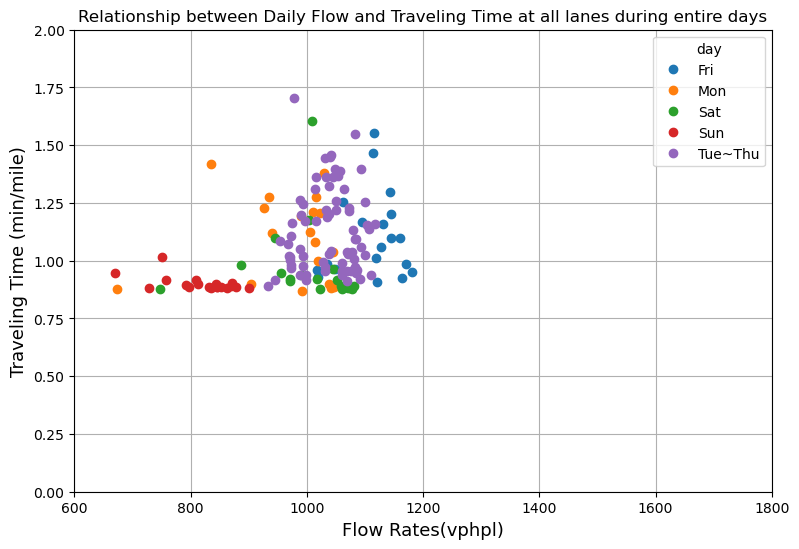

In [7]:
# Check the relationship between flow and time for the entire period

# Step 0: Create an empty DataFrame to store daily traffic data and set basic variables
traffic_day = pd.DataFrame({'speed': [], 'time': [], 'flow': [], 'density': [],'year':[],'day':[]})

# option: 'two-peak_days', 'entire days'
dataset_days = 'entire days'
# label_criterion: 'year', 'day'
label_criterion = 'day'
# lane range: 'all lanes' '1,2 lanes'
lane_range = 'all lanes'
year_range = ['11','14','24']

if (dataset_days == 'entire days'):
    Dataset = file_list
else:
    Dataset = two_peak_dates

# for i, file_name in enumerate(Dataset):
#     # Step 1: Load data for each day and process it
#     # Load raw data from csv file
#     rawdata = rawdata_setting(directory,file_name)
#     date = file_name[-11:]
#     year = f'20{date[0:2]}'
#     day_list = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
#     day = day_list[int(rawdata.loc[0,'time'].weekday())]
    
#     gfactor = pd.read_excel(f'{path}/gfactor/gfactor_{date}')

#     # Step 2: Calculate the average traffic state for the day
#     avg_speed, avg_time, avg_flow, avg_density = avg_traffic_state(rawdata, raw_timeframe, lane_num, gfactor)

#     # Append daily traffic state to the DataFrame
#     traffic_day.loc[i] = [avg_speed, avg_time, avg_flow, avg_density, year, day]

# with open(f'traffic_day_{dataset_days}_{lane_range}.p', 'wb') as file:  
#     pickle.dump(traffic_day, file)

with open(f'traffic_day_{dataset_days}_{lane_range}.p', 'rb') as file:
    traffic_day = pickle.load(file)

traffic_day = traffic_day.iloc[np.where(traffic_day['year'].isin(year_range))]
# traffic_day = traffic_day.iloc[np.where(traffic_day['day'].isin(['Sat','Sun','Fri']))]

# Step 3: Create a scatter plot for 'flow' vs 'time'
fig, ax = plt.subplots(1, 1, figsize=(9, 6))

traffic_day.loc[traffic_day['day'].isin(['Tue','Wed','Thu']), 'day'] = 'Tue~Thu'
traffic_day = traffic_day.groupby(label_criterion)


for name, group in traffic_day:
    ax.plot(group["flow"], group["time"], marker="o", linestyle="", label=f"{name}")
    
plt.legend()

ax.set_title(f'Relationship between Daily Flow and Traveling Time at {lane_range} during {dataset_days}')
ax.set_ylabel('Traveling Time (min/mile)', fontsize=13)
ax.set_xlabel('Flow Rates(vphpl)', fontsize=13)
ax.grid(True)
ax.set_xlim([600,1800])
ax.set_ylim([0,2])
ax.legend(title=f'{label_criterion}')

# Save and Display the plot
plt.savefig(f'Daily_flow_vs_time_{lane_range}_{dataset_days}({year_range})_labeled by_{label_criterion}.png')
plt.show()

In [134]:
x = [0, 1.6, 1.7, 0, 0, 0, 0, 3, 3, 3, 3, 3, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 4, 4, 5, 5, 6, 7]
# peaks, properties = find_peaks(x, distance=5, plateau_size=2)

peaks, properties = find_peaks(x,height=2,distance=1)
# , width=5
print(peaks)
print(properties)

[9]
{'peak_heights': array([3.])}
